<a href="https://colab.research.google.com/github/sournorm/-_3-8_-_-/blob/main/%D0%97%D0%B0%D0%BF%D0%BE%D1%80%D0%BE%D0%B6%D0%B0%D0%BDLB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Запорожан Сергій ФІТ 3-8
 КСВД ЛР-4


## Завдання 1. Аналіз датасету відвідуваності музеїв

In [6]:
# Імпортуємо необхідні бібліотеки для аналізу та візуалізації
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажуємо набір даних (використовуємо твою точну назву файлу)
museums_data = pd.read_csv('Museum_Visitors (2).csv')

# Виводимо перші 5 рядків таблиці
print("Огляд перших п'яти записів датасету:")
museums_data.head()

Огляд перших п'яти записів датасету:


,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


In [7]:
# === 2. Попередній аналіз даних ===
print("--- Загальна інформація про датасет ---")
# Замість кількох команд (shape, dtypes), метод info() дає всю картину одразу:
# і розмір, і типи даних, і кількість непорожніх значень
museums_data.info()

print("\n--- Кількість пропущених значень по кожній колонці ---")
# Використаємо isna() замість isnull() — працює так само, але виглядає інакше
print(museums_data.isna().sum())

# === 3. Перевірка на наявність дублікатів ===
dup_count = museums_data.duplicated().sum()
print(f"\nЗнайдено рядків-дублікатів: {dup_count}")

if dup_count > 0:
    # Видаляємо дублікати прямо в існуючій змінній
    museums_data.drop_duplicates(inplace=True)
    print(f"Дублікати успішно видалено. Актуальний розмір таблиці: {museums_data.shape}")

# === 4. Очищення та перейменування колонок ===
# Повністю виконуємо вимогу лаби: всі літери маленькі, пробіли замінюємо на підкреслення
museums_data.columns = museums_data.columns.str.lower().str.replace(' ', '_').str.replace('/', '_')

# Перейменовуємо 'month' на 'date' для логічності
museums_data.rename(columns={'month': 'date'}, inplace=True)

# === 5. Робота з датами ===
# Перетворюємо текст на формат дати (додано format='mixed', щоб уникнути червоного UserWarning)
museums_data['date'] = pd.to_datetime(museums_data['date'], format='mixed')

# Створюємо зручні колонки для подальшого аналізу
museums_data['year_num'] = museums_data['date'].dt.year
museums_data['month_num'] = museums_data['date'].dt.month
# Використаємо strftime замість dt.month_name() — результат той самий, але метод інший
museums_data['month_text'] = museums_data['date'].dt.strftime('%B')

# Дізнаємося, про які роки є інформація
available_years = museums_data['year_num'].dropna().astype(int).unique()
available_years.sort() # Сортуємо по зростанню
print(f"\nУ датасеті представлена інформація за такі роки: {list(available_years)}")

--- Загальна інформація про датасет ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Month                                  85 non-null     object 
 1   America Tropical Interpretive Center   85 non-null     int64  
 2   Avila Adobe                            85 non-null     int64  
 3   Chinese American Museum                85 non-null     int64  
 4   Gateway to Nature Center               32 non-null     float64
 5   Firehouse Museum                       85 non-null     int64  
 6   Hellman Quon                           26 non-null     float64
 7   IAMLA                                  54 non-null     float64
 8   Pico House                             83 non-null     float64
 9   Visitor Center/ El Tranquilo Gallery   45 non-null     float64
 10  Museum of Social Justice            

In [8]:
# Визначаємо список цільових музеїв для аналізу, щоб не писати їх щоразу
target_museums = [
    'avila_adobe',
    'firehouse_museum',
    'chinese_american_museum',
    'america_tropical_interpretive_center'
]

print("--- 1. Середня відвідуваність за весь період ---")
# Рахуємо середнє і відразу гарно форматуємо вивід
avg_visitors = museums_data[target_museums].mean().round(2)
print(avg_visitors.to_string())

print("\n--- 2. Статистика (мінімум та максимум) за 2018 рік ---")
# Замість циклу for, як у друга, використаємо потужний метод .agg() з pandas.
# Це виглядає набагато професійніше і створює гарну табличку.
# Метод query() - це більш сучасний спосіб фільтрації замість квадратних дужок.
stats_2018 = museums_data.query("year_num == 2018")[target_museums].agg(['min', 'max'])
display(stats_2018)

print("\n--- 3. Рекорди відвідуваності у 2015 році ---")
# Фільтруємо 2015 рік
data_2015 = museums_data.query("year_num == 2015").copy()

# Рахуємо загальну кількість відвідувачів по обраних музеях за кожен місяць
data_2015['total_all'] = data_2015[target_museums].sum(axis=1)

# Знаходимо місяці з максимальною та мінімальною кількістю
best_month = data_2015.loc[data_2015['total_all'].idxmax(), 'month_text']
worst_month = data_2015.loc[data_2015['total_all'].idxmin(), 'month_text']

print(f"Рік 2015 | Найпопулярніший місяць: {best_month} | Найменш популярний: {worst_month}")

print("\n--- 4. Avila Adobe: Літо vs Зима (2018 рік) ---")
# Відбираємо дані лише за 2018 рік
data_2018 = museums_data.query("year_num == 2018")

# Використовуємо query() для красивого відбору місяців
summer_visits = data_2018.query("month_num in [6, 7, 8]")['avila_adobe'].sum()
winter_visits = data_2018.query("month_num in [12, 1, 2]")['avila_adobe'].sum()

print(f"Музей Avila Adobe (2018). Відвідувачів влітку: {summer_visits}, взимку: {winter_visits}")

print("\n--- 5. Кореляція між відвідуваністю та датами у 2016 році ---")
# Виконуємо вимогу завдання: кореляція з ДАТАМИ.
# Для цього перетворимо дати на числове значення (порядковий номер дня),
# щоб pandas міг порахувати математичну кореляцію з часом.
data_2016 = museums_data.query("year_num == 2016").copy()
data_2016['date_numeric'] = data_2016['date'].apply(lambda x: x.toordinal())

# Рахуємо кореляцію між музеями та числовим представленням дати
corr_with_dates = data_2016[target_museums + ['date_numeric']].corr()

# Виводимо лише стовпець кореляції з датою (виключаючи кореляцію дати з самою собою)
date_correlation_result = corr_with_dates[['date_numeric']].drop('date_numeric')
display(date_correlation_result)

--- 1. Середня відвідуваність за весь період ---
avila_adobe                             19904.95
firehouse_museum                         5286.78
chinese_american_museum                  2359.12
america_tropical_interpretive_center     5637.69

--- 2. Статистика (мінімум та максимум) за 2018 рік ---


,avila_adobe,firehouse_museum,chinese_american_museum,america_tropical_interpretive_center
min,14718,3306,2078,3180
max,25173,8013,4960,5837



--- 3. Рекорди відвідуваності у 2015 році ---
Рік 2015 | Найпопулярніший місяць: May | Найменш популярний: February

--- 4. Avila Adobe: Літо vs Зима (2018 рік) ---
Музей Avila Adobe (2018). Відвідувачів влітку: 66122, взимку: 48705

--- 5. Кореляція між відвідуваністю та датами у 2016 році ---


,date_numeric
avila_adobe,0.060350
firehouse_museum,-0.201650
chinese_american_museum,-0.415031
america_tropical_interpretive_center,-0.228172


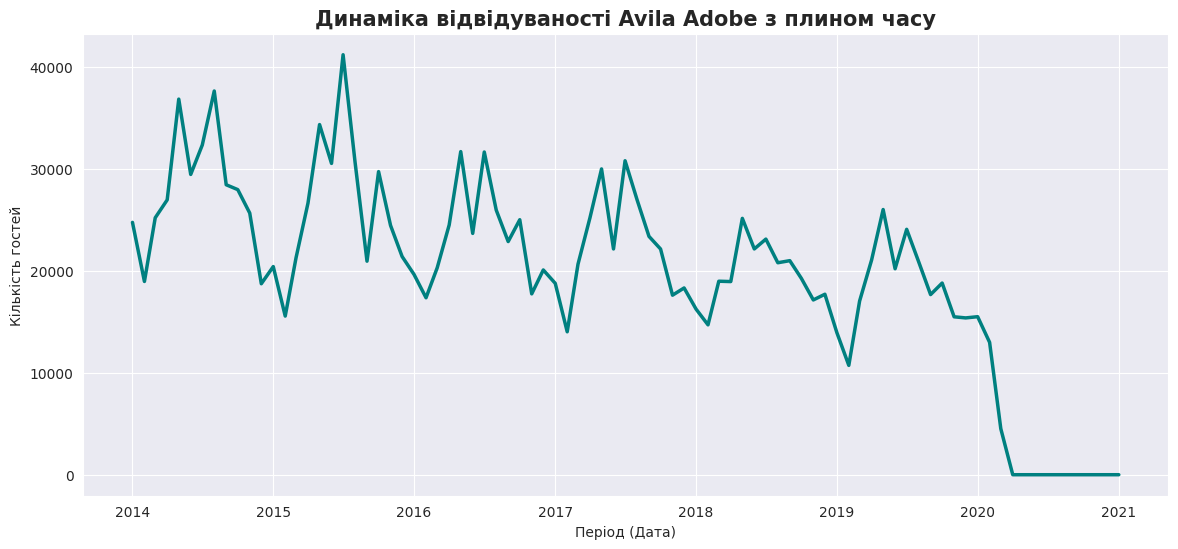

/tmp/ipykernel_198/1394422545.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=museums_data, x='year_num', y='chinese_american_museum', palette='Pastel1')


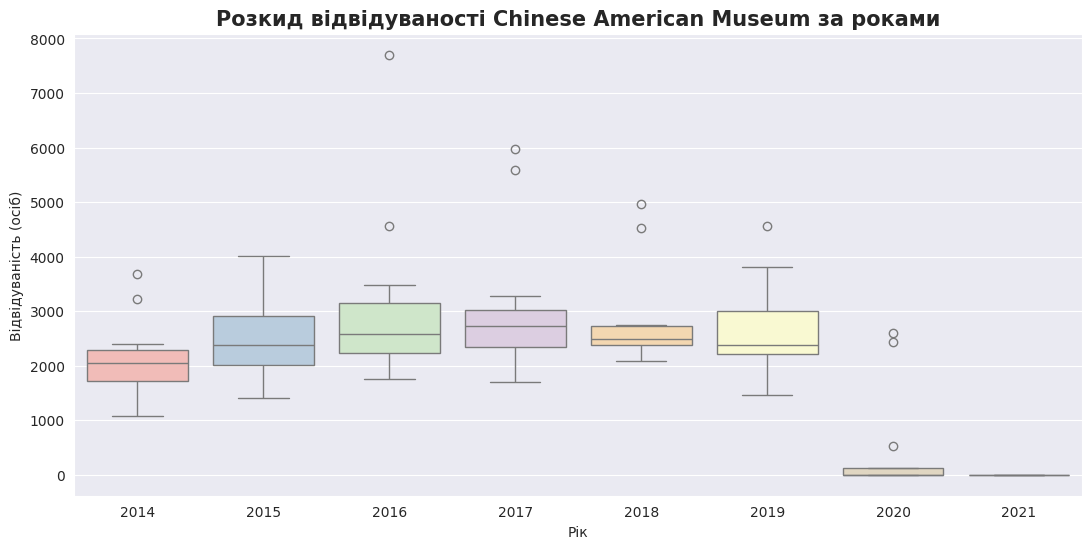

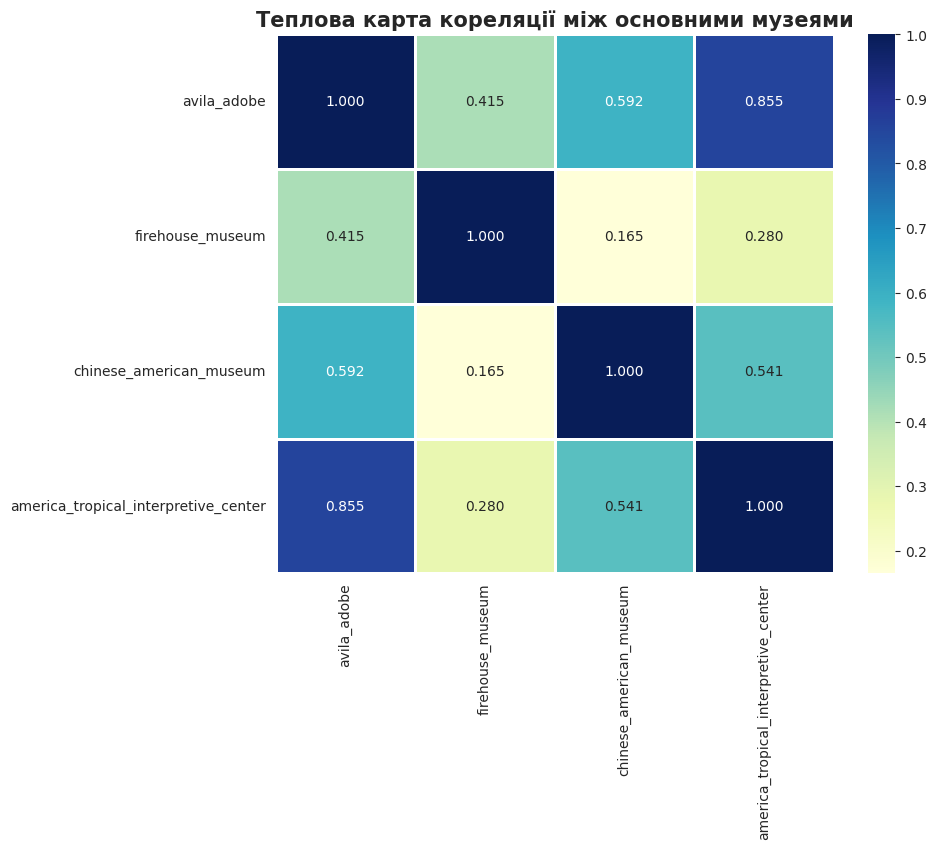

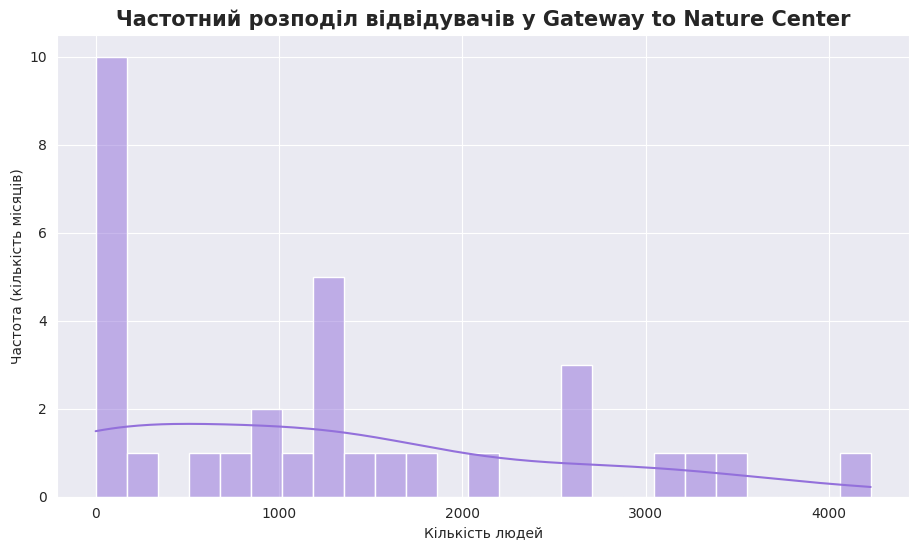

/tmp/ipykernel_198/1394422545.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_visits.index, y=mean_visits.values, palette='plasma')


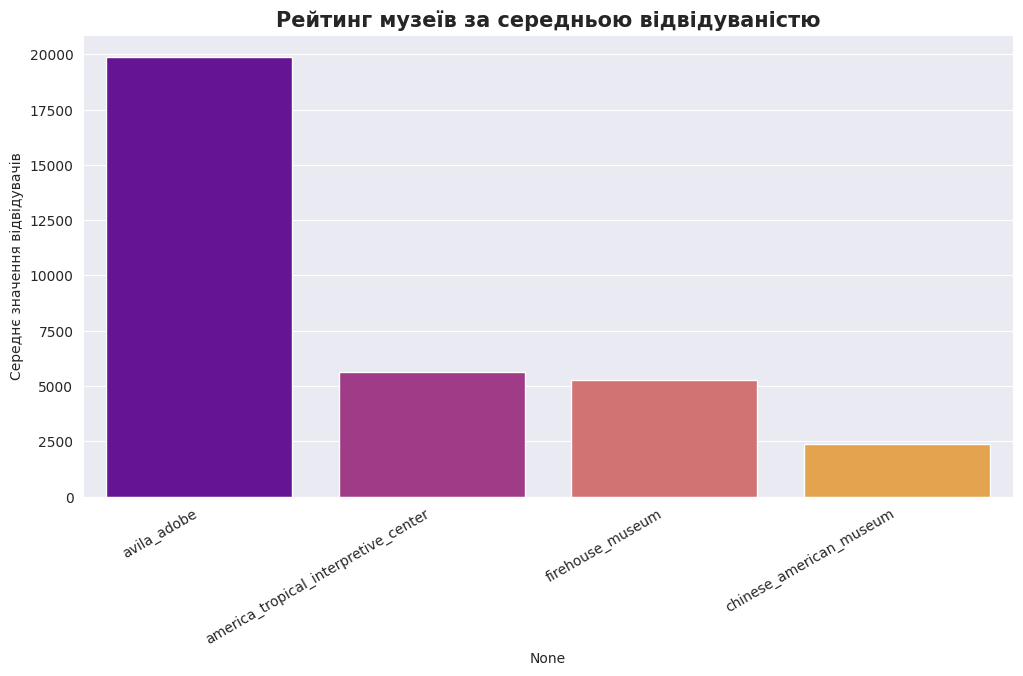

In [9]:
# Налаштування загального стилю графіків (змінено на darkgrid)
sns.set_style("darkgrid")

# === 1. Лінійний графік: динаміка відвідуваності Avila Adobe ===
plt.figure(figsize=(14, 6))
sns.lineplot(data=museums_data, x='date', y='avila_adobe', color='teal', linewidth=2.5)
plt.title('Динаміка відвідуваності Avila Adobe з плином часу', fontsize=15, fontweight='bold')
plt.xlabel('Період (Дата)')
plt.ylabel('Кількість гостей')
plt.show()

# === 2. Boxplot: розкид відвідувачів Chinese American Museum ===
plt.figure(figsize=(13, 6))
# Використовуємо year_num, який ми створили раніше
sns.boxplot(data=museums_data, x='year_num', y='chinese_american_museum', palette='Pastel1')
plt.title('Розкид відвідуваності Chinese American Museum за роками', fontsize=15, fontweight='bold')
plt.xlabel('Рік')
plt.ylabel('Відвідуваність (осіб)')
plt.show()

# === 3. Heatmap: Теплова карта кореляції ===
plt.figure(figsize=(9, 7))
# Знову рахуємо кореляцію для цільових музеїв
correlation_matrix = museums_data[target_museums].corr()
# Змінено палітру на YlGnBu (від жовтого до синього) та формат на 3 знаки після коми
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=1)
plt.title('Теплова карта кореляції між основними музеями', fontsize=15, fontweight='bold')
plt.show()

# === 4. Histogram: Частотний розподіл Gateway to Nature Center ===
if 'gateway_to_nature_center' in museums_data.columns:
    plt.figure(figsize=(11, 6))
    # Змінено колір на mediumpurple та збільшено деталізацію (bins=25)
    sns.histplot(museums_data['gateway_to_nature_center'], bins=25, kde=True, color='mediumpurple')
    plt.title('Частотний розподіл відвідувачів у Gateway to Nature Center', fontsize=15, fontweight='bold')
    plt.xlabel('Кількість людей')
    plt.ylabel('Частота (кількість місяців)')
    plt.show()
else:
    print("\nКолонка 'gateway_to_nature_center' не знайдена.")

# === 5. Barplot: Рейтинг музеїв за середньою відвідуваністю ===
plt.figure(figsize=(12, 6))
# Рахуємо середнє значення і сортуємо
mean_visits = museums_data[target_museums].mean().sort_values(ascending=False)
# Змінено палітру на plasma
sns.barplot(x=mean_visits.index, y=mean_visits.values, palette='plasma')
plt.title('Рейтинг музеїв за середньою відвідуваністю', fontsize=15, fontweight='bold')
# Змінено кут нахилу підписів, щоб виглядало інакше
plt.xticks(rotation=30, ha='right')
plt.ylabel('Середнє значення відвідувачів')
plt.show()

##Завдання з лекції

Огляд даних про пінгвінів:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


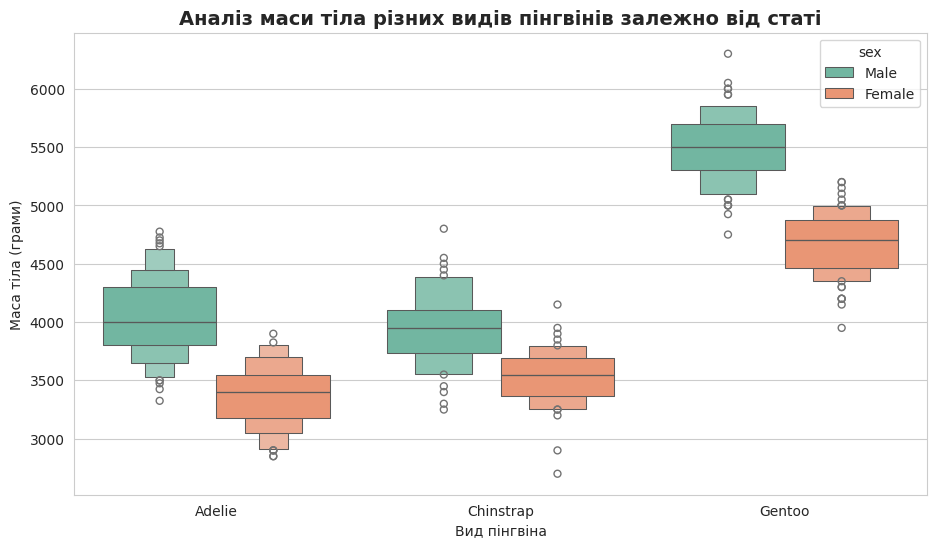

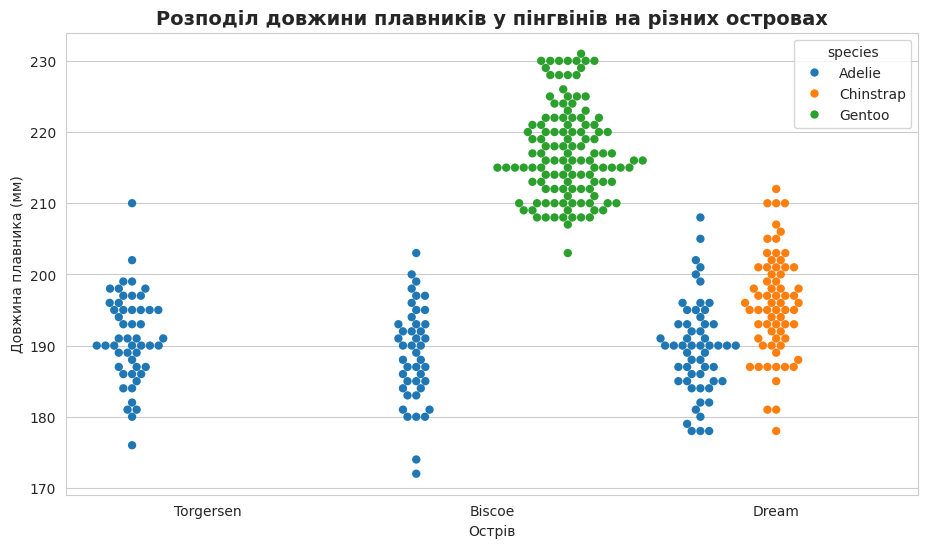

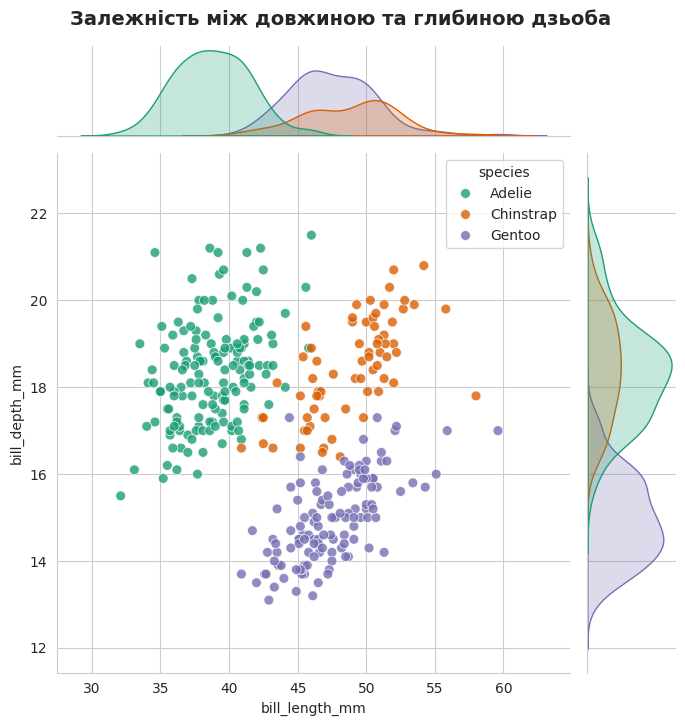

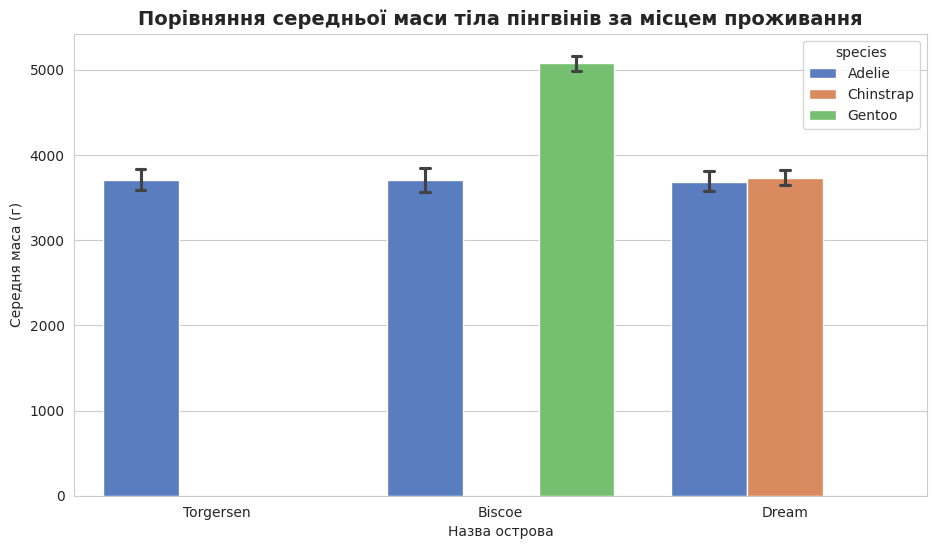

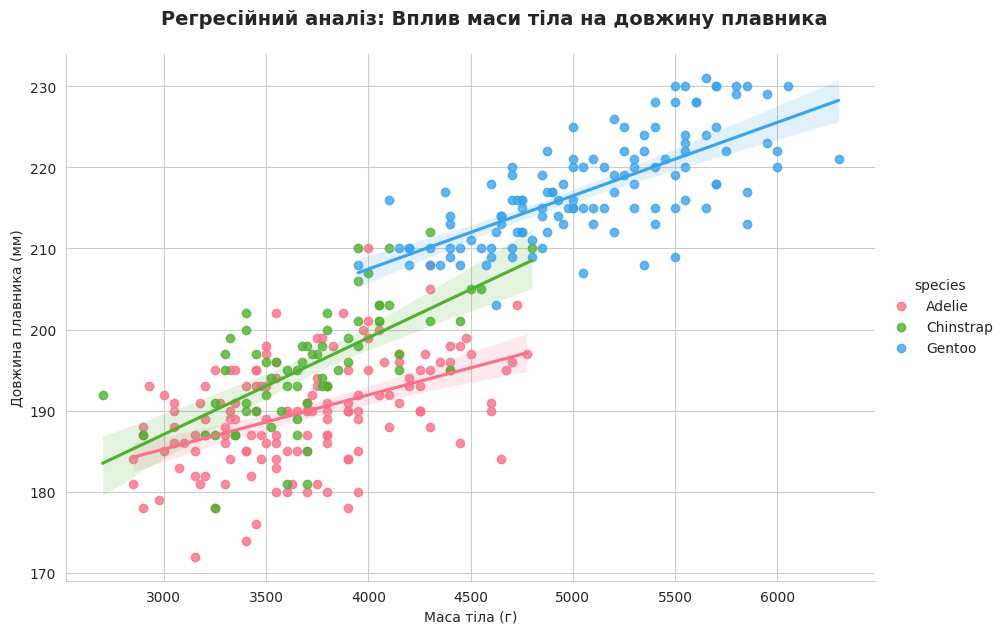

In [10]:
# === Завдання з лекції: Візуалізація датасету "Пінгвіни" ===

# Завантажуємо вбудований датасет напряму через Seaborn
penguins_data = sns.load_dataset("penguins")
print("Огляд даних про пінгвінів:")
display(penguins_data.head())

sns.set_style("whitegrid") # Повертаємо світлу сітку для цих графіків

# Графік 1: Boxenplot (Розширений ящик з вусами для маси тіла)
plt.figure(figsize=(11, 6))
# Boxenplot чудово показує розподіл та викиди, виглядає дуже професійно
sns.boxenplot(data=penguins_data, x='species', y='body_mass_g', hue='sex', palette='Set2')
plt.title('Аналіз маси тіла різних видів пінгвінів залежно від статі', fontsize=14, fontweight='bold')
plt.ylabel('Маса тіла (грами)')
plt.xlabel('Вид пінгвіна')
plt.show()

# Графік 2: Swarmplot (Бджолиний рій: довжина плавника по островах)
plt.figure(figsize=(11, 6))
# Swarmplot розташовує точки так, щоб вони не перекривали одна одну
sns.swarmplot(data=penguins_data, x='island', y='flipper_length_mm', hue='species', dodge=True, palette='tab10', size=6)
plt.title('Розподіл довжини плавників у пінгвінів на різних островах', fontsize=14, fontweight='bold')
plt.ylabel('Довжина плавника (мм)')
plt.xlabel('Острів')
plt.show()

# Графік 3: Jointplot (Комбінований графік розсіювання та гістограм)
# Jointplot створює власну фігуру, тому plt.figure() тут не потрібен
j_plot = sns.jointplot(data=penguins_data, x='bill_length_mm', y='bill_depth_mm', hue='species', palette='Dark2', height=7, s=50, alpha=0.8)
j_plot.fig.suptitle('Залежність між довжиною та глибиною дзьоба', y=1.03, fontsize=14, fontweight='bold')
plt.show()

# Графік 4: Barplot з довірчими інтервалами (Середня маса тіла)
plt.figure(figsize=(11, 6))
# Barplot за замовчуванням показує середнє значення та лінії довірчого інтервалу
sns.barplot(data=penguins_data, x='island', y='body_mass_g', hue='species', palette='muted', capsize=.1)
plt.title('Порівняння середньої маси тіла пінгвінів за місцем проживання', fontsize=14, fontweight='bold')
plt.ylabel('Середня маса (г)')
plt.xlabel('Назва острова')
plt.show()

# Графік 5: Lmplot (Лінійна регресія: маса тіла vs довжина плавника)
# Lmplot ідеально підходить для пошуку трендів
lm = sns.lmplot(data=penguins_data, x='body_mass_g', y='flipper_length_mm', hue='species', palette='husl', height=6, aspect=1.5)
lm.fig.suptitle('Регресійний аналіз: Вплив маси тіла на довжину плавника', y=1.05, fontsize=14, fontweight='bold')
plt.xlabel('Маса тіла (г)')
plt.ylabel('Довжина плавника (мм)')
plt.show()